In [1]:
import json
import random

# Generate mock API data
categories = ['Python', 'Web3', 'AI', 'Startups', 'SaaS', 'Design', 'Fintech']
raw_api_data = []

for i in range(1, 201): # 200 users
    user_data = {
        "id": f"BLR_{i}",
        "username": f"indiranagar_coder_{i}",
        "profile": {
            # Injecting messy data: some users have no follower count
            "followers": random.randint(10, 10000) if random.random() > 0.1 else None,
            "location": "Indiranagar, Bangalore"
        },
        "posts": []
    }

    # Generate random posts for each user
    num_posts = random.randint(0, 50)
    for p in range(num_posts):
        user_data["posts"].append({
            "post_id": f"P_{i}_{p}",
            "likes": random.randint(0, 500),
            # Injecting messy data: some posts have missing categories
            "category": random.choice(categories) if random.random() > 0.15 else None
        })

    raw_api_data.append(user_data)

# Convert to a JSON string to simulate an incoming API payload
json_payload = json.dumps(raw_api_data)
print("Mock JSON API payload generated successfully!")

Mock JSON API payload generated successfully!


In [2]:
# Load the JSON data
parsed_data = json.loads(json_payload)

# Initialize dictionaries to hold our cleaned, structured data
user_metrics = {}

for user in parsed_data:
    uid = user["username"]

    # 1. Clean Followers (Handle the None values)
    raw_followers = user["profile"]["followers"]
    clean_followers = raw_followers if raw_followers is not None else 0

    # 2. Process Posts & Categories
    post_count = len(user["posts"])
    user_categories = set() # Use a set to automatically handle unique categories

    for post in user["posts"]:
        cat = post["category"]
        if cat is not None:
            user_categories.add(cat)

    # 3. Store in our structured dictionary
    user_metrics[uid] = {
        "followers": clean_followers,
        "total_posts": post_count,
        "unique_categories": len(user_categories),
        "category_list": list(user_categories)
    }

print(f"Successfully parsed and cleaned data for {len(user_metrics)} users.")

Successfully parsed and cleaned data for 200 users.


In [3]:
# Calculate Influence Score and rank users
for uid, metrics in user_metrics.items():
    # Weighting the metrics to create a balanced score
    score = (metrics["followers"] * 0.5) + (metrics["total_posts"] * 50) + (metrics["unique_categories"] * 100)
    user_metrics[uid]["influence_score"] = round(score, 2)

# Sort users by influence score in descending order
ranked_influencers = sorted(user_metrics.items(), key=lambda x: x[1]["influence_score"], reverse=True)

print("🏆 Top 5 Multi-Dimensional Influencers in Indiranagar:")
for i in range(5):
    uid, data = ranked_influencers[i]
    print(f"{i+1}. {uid} | Score: {data['influence_score']} | Followers: {data['followers']} | Posts: {data['total_posts']} | Topics: {data['unique_categories']}")

🏆 Top 5 Multi-Dimensional Influencers in Indiranagar:
1. indiranagar_coder_84 | Score: 8106.5 | Followers: 9813 | Posts: 50 | Topics: 7
2. indiranagar_coder_67 | Score: 8027.5 | Followers: 9655 | Posts: 50 | Topics: 7
3. indiranagar_coder_95 | Score: 7773.0 | Followers: 9146 | Posts: 50 | Topics: 7
4. indiranagar_coder_49 | Score: 7623.5 | Followers: 8847 | Posts: 50 | Topics: 7
5. indiranagar_coder_14 | Score: 7500.0 | Followers: 9300 | Posts: 43 | Topics: 7


C:\Users\shiva\AppData\Local\Temp\ipykernel_28804\3740320270.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='influence_score', y='username', data=top_10_df, palette="magma")


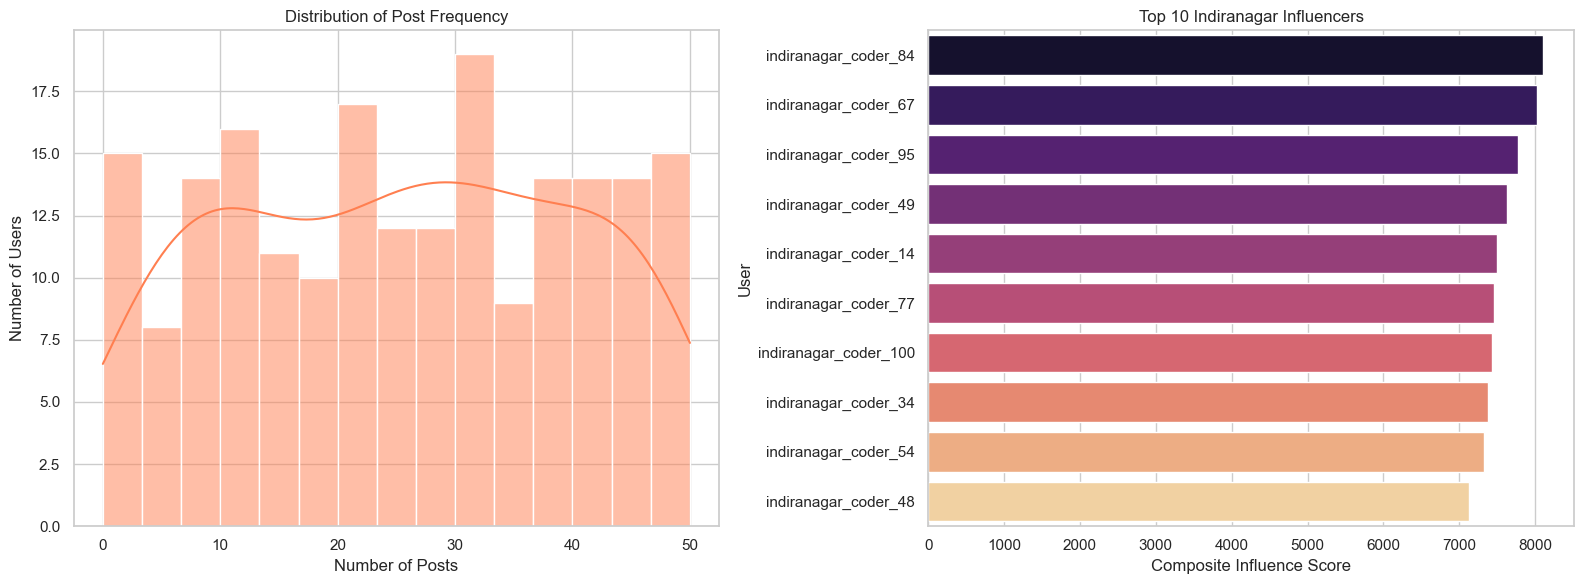

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert our structured dictionary to a Pandas DataFrame
df_influencers = pd.DataFrame.from_dict(user_metrics, orient='index').reset_index()
df_influencers.rename(columns={'index': 'username'}, inplace=True)

# Set up the visualization dashboard
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Distribution of Posts
plt.subplot(1, 2, 1)
sns.histplot(df_influencers['total_posts'], bins=15, kde=True, color='coral')
plt.title('Distribution of Post Frequency')
plt.xlabel('Number of Posts')
plt.ylabel('Number of Users')

# Plot 2: Top 10 Users by Influence Score
plt.subplot(1, 2, 2)
top_10_df = df_influencers.nlargest(10, 'influence_score')
sns.barplot(x='influence_score', y='username', data=top_10_df, palette="magma")
plt.title('Top 10 Indiranagar Influencers')
plt.xlabel('Composite Influence Score')
plt.ylabel('User')

plt.tight_layout()
plt.show()

In [5]:
import sqlite3
import pandas as pd

# THE FIX: Convert the 'category_list' (Python list) into a comma-separated string
df_influencers['category_list'] = df_influencers['category_list'].apply(lambda x: ', '.join(x))

# 1. Create a connection to a local SQLite database
conn = sqlite3.connect('indiranagar_data.db')

# 2. Export the cleaned DataFrame to an SQL table named 'influencers'
df_influencers.to_sql('influencers', conn, if_exists='replace', index=False)

print("✅ Data successfully loaded into SQLite database: indiranagar_data.db")

# 3. Test the database with a raw SQL Query
query = """
SELECT username, followers, total_posts, unique_categories, influence_score
FROM influencers
WHERE followers > 100 AND unique_categories > 2
ORDER BY influence_score DESC
LIMIT 5;
"""

# Execute the query and load the results back into a DataFrame
sql_results = pd.read_sql(query, conn)

print("\n🔍 Query Results (High-follower, Multi-topic Influencers):")
print(sql_results.to_string(index=False))

# Close the connection to free up memory
conn.close()

✅ Data successfully loaded into SQLite database: indiranagar_data.db

🔍 Query Results (High-follower, Multi-topic Influencers):
            username  followers  total_posts  unique_categories  influence_score
indiranagar_coder_84       9813           50                  7           8106.5
indiranagar_coder_67       9655           50                  7           8027.5
indiranagar_coder_95       9146           50                  7           7773.0
indiranagar_coder_49       8847           50                  7           7623.5
indiranagar_coder_14       9300           43                  7           7500.0
